# AICE 모의고사 1회 - 학생 성적 예측

## 문제 시나리오

학생들의 인구통계학적 정보와 학습 데이터를 분석하고 최종 성적을 예측하는 모델을 작성하세요.

---

## 1-1 | 라이브러리 임포트 및 데이터 로딩

### 【 문제 】

다음의 데이터를 pandas 라이브러리를 pd라는 별칭으로 임포트하고, 두 개의 데이터를 읽어 데이터프레임으로 할당하는 코드를 작성하세요.

- `student_demographics.csv` 파일을 읽어 데이터프레임 변수 `df_demographics`에 할당하세요.
- `course_grades.json` 파일을 읽어 데이터프레임 변수 `df_grades`에 할당하세요.

In [2]:
import pandas as pd

df_demographics = pd.read_csv('./student_demographics.csv')
df_grades = pd.read_json('./course_grades_1.json')

## 1-2 | 데이터 병합 및 초기 탐색

### 【 문제 】

두 개의 데이터프레임(`df_demographics`, `df_grades`)을 StudentID 컬럼을 기준으로 병합하고, 병합된 데이터프레임의 상위 5개 행과 컬럼별 요약 정보를 출력하여 2개 데이터를 탐색하는 코드를 작성하세요.

`pandas`의 merge 함수를 사용하여 `df_demographics`와 `df_grades`를 StudentID를 키(key)로 병합하고 df 변수에 저장하세요.
    - 병합 방식은 inner로 지정하세요.
    - df 데이터프레임의 상위 5 개 행을 출력하세요.
    - df 데이터프레임의 컬럼별 정보(dtype, Non-null Count)를 확인하세요.

In [5]:
df = pd.merge(df_demographics, df_grades, on='StudentID', how='inner')
df.head()

,StudentID,Age,Gender,ParentalEducation,StudyHours_per_week,Absences,PreviousGPA,MidtermScore,QuizAverage,ProjectScore,FinalScore
0,1,17,Female,University,39,22.0,3.52,55,85,98,94
1,2,18,Male,HighSchool,52,1.0,2.03,55,96,97,71
2,3,16,Male,College,29,9.0,2.23,70,65,70,97
3,4,18,Female,HighSchool,39,1.0,2.09,53,89,75,79
4,5,18,Female,HighSchool,29,16.0,2.08,80,83,73,52


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StudentID            98 non-null     int64  
 1   Age                  98 non-null     int64  
 2   Gender               98 non-null     object 
 3   ParentalEducation    92 non-null     object 
 4   StudyHours_per_week  98 non-null     int64  
 5   Absences             93 non-null     float64
 6   PreviousGPA          98 non-null     float64
 7   MidtermScore         98 non-null     int64  
 8   QuizAverage          98 non-null     int64  
 9   ProjectScore         98 non-null     int64  
 10  FinalScore           98 non-null     int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 8.6+ KB


## 1-3 | 범주형 변수 로트 시각화 및 데이터 경제

### 【 문제 】

ParentalEducation 컬럼의 분포를 시각화하고, 데이터 경제를 위해 'N/A' 값을 가진 행을 제거하는 코드를 작성하세요.

- seaborn 라이브러리의 countplot을 사용하여 ParentalEducation 컬럼의 분포를 시각화하세요.
- ParentalEducation 컬럼 값이 'N/A'인 행을 데이터프레임에서 삭제하세요.

<Axes: xlabel='count', ylabel='ParentalEducation'>

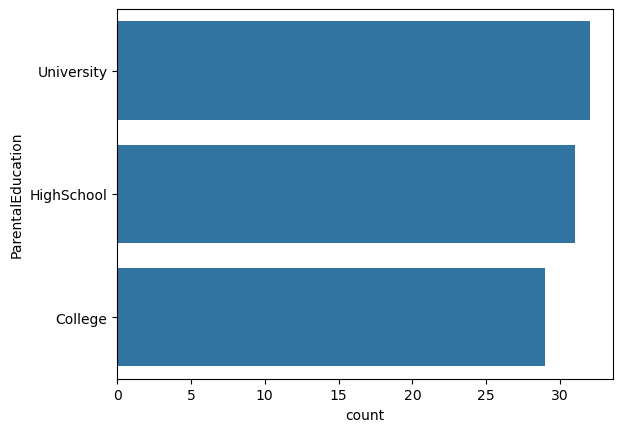

In [8]:
# 봐봐 ParentalEducation은 범주형이니까 countplot이어야겠지(설명 있네 -> 연속형이라면 hisplot)
import seaborn as sns
sns.countplot(data=df['ParentalEducation'])

In [10]:
df = df[df['ParentalEducation'] != 'N/A'].copy()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 98 entries, 0 to 97
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   StudentID            98 non-null     int64  
 1   Age                  98 non-null     int64  
 2   Gender               98 non-null     object 
 3   ParentalEducation    92 non-null     object 
 4   StudyHours_per_week  98 non-null     int64  
 5   Absences             93 non-null     float64
 6   PreviousGPA          98 non-null     float64
 7   MidtermScore         98 non-null     int64  
 8   QuizAverage          98 non-null     int64  
 9   ProjectScore         98 non-null     int64  
 10  FinalScore           98 non-null     int64  
dtypes: float64(2), int64(7), object(2)
memory usage: 8.6+ KB


## 1-4 | 수치형 변수 관계 시각화 및 이상치 탐색

### 【 문제 】

StudyHours_per_week와 FinalScore 간의 관계를 jointplot으로 시각화하고, StudyHours_per_week가 50 이상인 이상치 값의 개수를 확인하는 코드를 작성하세요.

- seaborn 라이브러리의 jointplot을 사용하여 x축에 StudyHours_per_week, y축에 FinalScore를 표시하세요.
- StudyHours_per_week가 50 이상인 행의 개수를 세어 출력하세요.

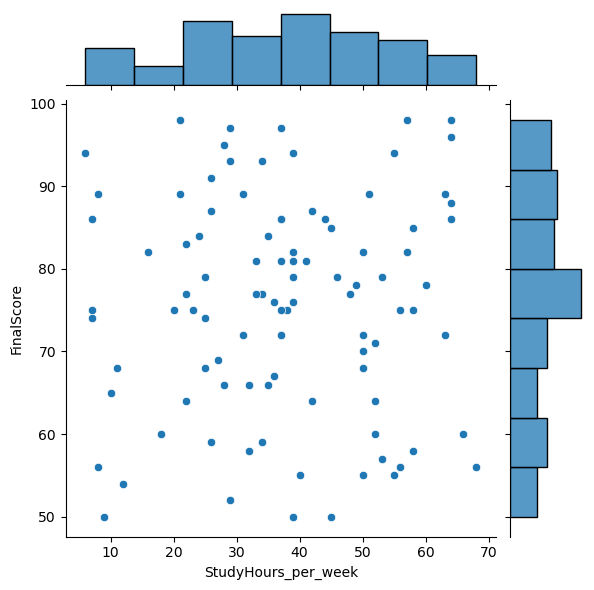

In [11]:
sns.jointplot(data=df, x='StudyHours_per_week', y='FinalScore')

In [12]:
outlier_count = df[df['StudyHours_per_week'] >= 50].shape[0]
print(outlier_count)

29


## 1-5 | 이상치 및 결측인 컬럼 처리

### 【 문제 】

StudyHours_per_week가 50 이상인 이상치 행을 삭제하고, 모델링에 불필요한 StudentID 컬럼을 삭제하는 코드를 작성하세요.

- StudyHours_per_week가 50 미만인 행만 남기고 데이터프레임을 업데이트하세요.
- StudentID 컬럼을 데이터프레임에서 삭제하세요.
- 변경된 데이터프레임을 새로운 변수 df_cleaned에 저장하세요.

In [15]:
df_cleaned = df[df['StudyHours_per_week'] < 50].copy()
df_cleaned = df_cleaned.drop('StudentID', axis=1)

df_cleaned.head()

,Age,Gender,ParentalEducation,StudyHours_per_week,Absences,PreviousGPA,MidtermScore,QuizAverage,ProjectScore,FinalScore
0,17,Female,University,39,22.0,3.52,55,85,98,94
2,16,Male,College,29,9.0,2.23,70,65,70,97
3,18,Female,HighSchool,39,1.0,2.09,53,89,75,79
4,18,Female,HighSchool,29,16.0,2.08,80,83,73,52
5,16,Male,College,22,NaN,3.41,55,61,84,77


In [16]:
df_cleaned.info()

<class 'pandas.core.frame.DataFrame'>
Index: 69 entries, 0 to 97
Data columns (total 10 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Age                  69 non-null     int64  
 1   Gender               69 non-null     object 
 2   ParentalEducation    66 non-null     object 
 3   StudyHours_per_week  69 non-null     int64  
 4   Absences             65 non-null     float64
 5   PreviousGPA          69 non-null     float64
 6   MidtermScore         69 non-null     int64  
 7   QuizAverage          69 non-null     int64  
 8   ProjectScore         69 non-null     int64  
 9   FinalScore           69 non-null     int64  
dtypes: float64(2), int64(6), object(2)
memory usage: 5.9+ KB


## 1-6 | 결측치 처리 및 데이터 타입 변환

### 【 문제 】

데이터프레임에 결측치가 있는지 확인하고, 결측치가 있는 행을 삭제한 뒤, Absences 컬럼을 정수형(int)으로 변환하세요.

- `df_cleaned`의 결측치를 확인하는 코드를 작성하세요.
- 결측치가 있는 모든 행을 삭제하세요.
- Absences 컬럼의 데이터 타입을 int로 변환하세요.
- 변경된 데이터프레임을 `df_processed` 변수에 저장하세요.

In [19]:
df_cleaned.isna().sum()
df_processed = df_cleaned.dropna().copy()

df_processed['Absences'] = df_processed['Absences'].astype(int)

df_processed.isna().sum()

Age                    0
Gender                 0
ParentalEducation      0
StudyHours_per_week    0
Absences               0
PreviousGPA            0
MidtermScore           0
QuizAverage            0
ProjectScore           0
FinalScore             0
dtype: int64

## 1-7 | 불필요 컬럼 처리 및 범주형 변수 원-핫 인코딩

### 【 문제 】

컬럼을 삭제하고, object 타입의 범주형 컬럼(Gender, ParentalEducation)을 원-핫 인코딩하세요.

- `df_processed`에서 Age 컬럼을 삭제하세요.
- pandas의 get_dummies 함수를 활용하여 object 타입의 컬럼에 대해 원-핫 인코딩을 수행하세요.
- 변경된 컬럼명 `df_encoded` 변수에 저장하세요.

In [22]:
df_encoded = df_processed.drop('Age', axis=1).copy()
df_encoded.info()

df_encoded = pd.get_dummies(df_encoded, columns=['Gender', 'ParentalEducation'])

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 9 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               62 non-null     object 
 1   ParentalEducation    62 non-null     object 
 2   StudyHours_per_week  62 non-null     int64  
 3   Absences             62 non-null     int64  
 4   PreviousGPA          62 non-null     float64
 5   MidtermScore         62 non-null     int64  
 6   QuizAverage          62 non-null     int64  
 7   ProjectScore         62 non-null     int64  
 8   FinalScore           62 non-null     int64  
dtypes: float64(1), int64(6), object(2)
memory usage: 4.8+ KB


In [23]:
df_encoded.head()

,StudyHours_per_week,Absences,PreviousGPA,MidtermScore,QuizAverage,ProjectScore,FinalScore,Gender_Female,Gender_Male,ParentalEducation_College,ParentalEducation_HighSchool,ParentalEducation_University
0,39,22,3.52,55,85,98,94,True,False,False,False,True
2,29,9,2.23,70,65,70,97,False,True,True,False,False
3,39,1,2.09,53,89,75,79,True,False,False,True,False
4,29,16,2.08,80,83,73,52,True,False,False,True,False
7,22,10,2.20,98,89,66,64,False,True,False,False,True


In [24]:
df_encoded.info()

<class 'pandas.core.frame.DataFrame'>
Index: 62 entries, 0 to 97
Data columns (total 12 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   StudyHours_per_week           62 non-null     int64  
 1   Absences                      62 non-null     int64  
 2   PreviousGPA                   62 non-null     float64
 3   MidtermScore                  62 non-null     int64  
 4   QuizAverage                   62 non-null     int64  
 5   ProjectScore                  62 non-null     int64  
 6   FinalScore                    62 non-null     int64  
 7   Gender_Female                 62 non-null     bool   
 8   Gender_Male                   62 non-null     bool   
 9   ParentalEducation_College     62 non-null     bool   
 10  ParentalEducation_HighSchool  62 non-null     bool   
 11  ParentalEducation_University  62 non-null     bool   
dtypes: bool(5), float64(1), int64(6)
memory usage: 4.2 KB


## 1-8 | 데이터 분리 및 스케일링

### 【 문제 】

최종 성적(FinalScore)을 예측하기 위해 데이터를 훈련 및 검증 데이터로 분리하고, 스케일링을 수행하세요.

- FinalScore 컬럼을 y 변수에, 나머지 컬럼을 X 변수에 할당하세요.
- scikit-learn의 train_test_split 함수를 사용하여 X와 y를 훈련 데이터(80%)와 검증 데이터(20%)로 분리하세요. random_state는 42로 설정하세요.
- sklearn.preprocessing의 RobustScaler를 사용하여 훈련 데이터와의 Feature(X_train)를 스케일링하고 X_train_scaled에 할당하세요.
- RobustScaler의 transform 함수를 사용하여 검증 데이터와의 Feature(X_valid)를 스케일링하고 X_valid_scaled에 할당하세요.

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import RobustScaler

rs = RobustScaler()

X = df_encoded.drop('FinalScore', axis=1)
y = df_encoded['FinalScore']

X_train, X_valid, y_train, y_valid = train_test_split(X, y, random_state=442, test_size=0.2)

X_train_scaled = rs.fit_transform(X_train)
X_valid_scaled = rs.fit_transform(X_valid)

## 1-9 | 머신러닝 모델 학습(Gradient Boosting Regressor)

### 【 문제 】

scikit-learn의 GradientBoostingRegressor 모델을 생성하고 학습하세요.

- 모델의 n_estimators는 100, learning_rate는 0.1, max_depth는 3, random_state는 42로 설정하세요.
- 모델을 gbr_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [34]:
from sklearn.ensemble import GradientBoostingRegressor

gbr_model = GradientBoostingRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)
gbr_model.fit(X_train_scaled, y_train)

,loss,'squared_error'
,learning_rate,0.1
,n_estimators,100
,subsample,1.0
,criterion,'friedman_mse'
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_depth,3
,min_impurity_decrease,0.0
,init,None


## 1-10 | 머신러닝 모델 학습(XGBoost Regressor)

### 【 문제 】

boost 라이브러리의 XGBRegressor 모델을 생성하고 학습하세요.

- XGBoost는 100, learning_rate는 0.1, max_depth는 3, random_state는 42로 설정하세요.
- 모델을 xgb_model 변수에 저장하고, 훈련 데이터(X_train_scaled, y_train)으로 학습을 진행하세요.

In [36]:
!pip install xgboost
import xgboost as xbg

   ---------------------------------------- 0.0/101.7 MB ? eta -:--:--
   --- ------------------------------------ 7.9/101.7 MB 41.3 MB/s eta 0:00:03
   ------- -------------------------------- 18.9/101.7 MB 46.3 MB/s eta 0:00:02
   ---------- ----------------------------- 27.0/101.7 MB 44.8 MB/s eta 0:00:02
   -------------- ------------------------- 36.4/101.7 MB 44.1 MB/s eta 0:00:02
   --------------- ------------------------ 40.6/101.7 MB 38.8 MB/s eta 0:00:02
   -------------------- ------------------- 51.4/101.7 MB 40.8 MB/s eta 0:00:02
   ------------------------ --------------- 62.9/101.7 MB 42.7 MB/s eta 0:00:01
   ----------------------------- ---------- 74.2/101.7 MB 43.9 MB/s eta 0:00:01
   --------------------------------- ------ 84.1/101.7 MB 44.2 MB/s eta 0:00:01
   ------------------------------------- -- 95.2/101.7 MB 45.2 MB/s eta 0:00:01
   --------------------------------------  101.4/101.7 MB 45.5 MB/s eta 0:00:01
   --------------------------------------  101.4/1

In [38]:
import xgboost as xgb

xgb_model = xgb.XGBRegressor(n_estimators = 100, learning_rate = 0.1, max_depth = 3, random_state = 42)

xgb_model.fit(X_train_scaled, y_train)

,objective,'reg:squarederror'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


## 1-11 | 머신러닝 모델 성능 평가(MAE 비교)

### 【 문제 】

두 머신러닝 모델(gbr_model, xgb_model)의 성능을 검증 데이터를 사용하여 MAE(Mean Absolute Error)로 평가하고, 더 낮은 성능을 보인 모델의 이름을 answer11 변수에 저장하세요.

- gbr_model과 xgb_model을 사용하여 검증 데이터(X_valid_scaled)에 대한 예측 값을 각각 gbr_pred, xgb_pred에 저장하세요.
- scikit-learn의 mean_absolute_error 함수를 사용하여 두 모델의 MAE를 계산하고 각각 gbr_mae, xgb_mae에 저장하세요.
- 더 낮은 MAE를 가진 모델의 이름을 answer11 변수에 저장하세요('GradientBoostingRegressor', 'XGBoostRegressor')에 저장하세요.

In [41]:
gbr_pred = gbr_model.predict(X_valid_scaled)
xgb_pred = xgb_model.predict(X_valid_scaled)

from sklearn.metrics import mean_absolute_error

gbr_mae = mean_absolute_error(y_valid, gbr_pred)
xgb_mae = mean_absolute_error(y_valid, xgb_pred)

print(gbr_mae)
print(xgb_mae)

10.154083417015935
8.71658992767334


In [ ]:
answer11 = 'XGBoostRegressor'

## 1-12 | 딥러닝 모델 개발 및 학습

### 【 문제 】

tensorflow.keras를 사용하여 FinalScore를 예측하는 딥러닝 모델을 만들어 학습하세요.

- 히든 레이어(Hidden Layer)를 2개 이상으로 구성하세요.
- Dropout 레이어를 1개 추가하고 비율을 0.2로 설정하세요.
- 손실 함수(loss function)는 mean_squared_error를 사용하세요.
- epoch는 30, batch_size는 16으로 설정하세요.
- 학습 과정에서 검증 데이터셋(X_valid_scaled, y_valid)을 사용하여 성능을 평가하고, 학습 정보를 history 변수에 저장하세요.

In [48]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dropout, Dense, Input

# 이거 옛날 코드임
# model = Sequential([
#     Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)),
#     Dropout(0.2),
#     Dense(32, activation='relu'),
#     Dense(1, activation='linear')
# ])

model = Sequential([
    Input(shape=(X_train_scaled.shape[1],)),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(32, activation='relu'),
    Dense(1, activation='linear')
])

model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae', 'mse'])

history = model.fit(
    x=X_train_scaled, 
    y=y_train, epochs=30, 
    batch_size=16, 
    validation_data=(X_valid_scaled, y_valid)
)

Epoch 1/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step - loss: 5951.4194 - mae: 75.9767 - mse: 5951.4194 - val_loss: 5913.5254 - val_mae: 76.2345 - val_mse: 5913.5254
Epoch 2/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5931.6558 - mae: 75.8445 - mse: 5931.6558 - val_loss: 5889.0146 - val_mae: 76.0776 - val_mse: 5889.0146
Epoch 3/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5896.0796 - mae: 75.6082 - mse: 5896.0796 - val_loss: 5865.6230 - val_mae: 75.9278 - val_mse: 5865.6230
Epoch 4/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - loss: 5877.0195 - mae: 75.4878 - mse: 5877.0195 - val_loss: 5842.6318 - val_mae: 75.7801 - val_mse: 5842.6318
Epoch 5/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step - loss: 5854.4683 - mae: 75.3269 - mse: 5854.4683 - val_loss: 5819.1138 - val_mae: 75.6285 - val_mse: 5819.1138
Epoch 6/30
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 27ms/step - loss: 5826.3120 - mae: 75.1362 - mse: 5826.3120 - val_loss: 5795.0107 - val_mae: 75.4728 - val_mse: 5795.0107
Epoch 7/30
4/4 ━━━━━━━━━━━━━━━━━━━

## 1-13 | 딥러닝 모델 학습 성능 시각화

### 【 문제 】

matplotlib을 활용하여 딥러닝 모델의 학습 MSE와 검증 MSE를 한 그래프에 표시하고, 반복이 증 데이터셋 검증하여 성능 변화를 시각화하세요.

- history 변수에 저장된 학습 MSE(loss)와 검증 MSE(val_loss)를 그래프로 그리세요.
- 각각의 변화를 'Training MSE'와 'Validation MSE'로 표시하세요.
- x축의 'Epochs', y축에 'MSE'라는 레이블을 지정하세요.

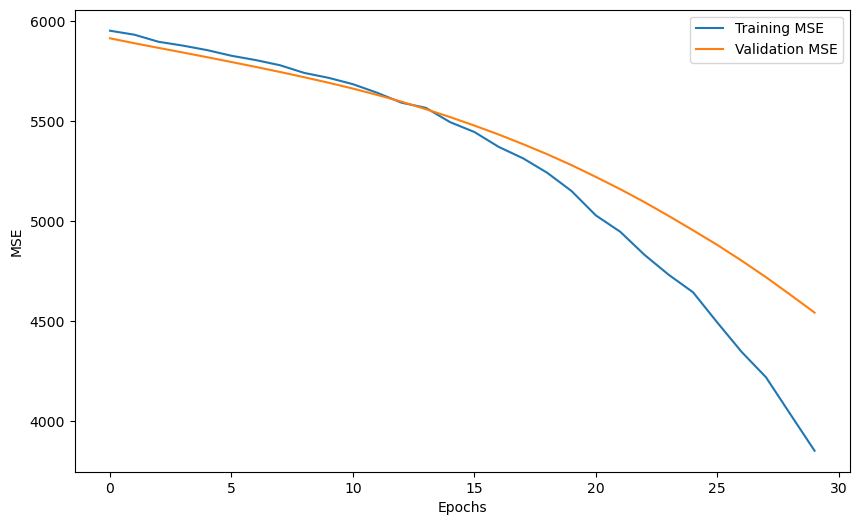

In [52]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.plot(history.history['mse'], label='Training MSE')
plt.plot(history.history['val_mse'], label='Validation MSE')
plt.xlabel('Epochs')
plt.ylabel('MSE')
plt.legend()
plt.show()

## 1-14 | 최종 모델 선택 및 결론 도출

### 【 문제 】

XGBoostRegressor와 딥러닝 모델의 평균 제곱 오차(MSE)를 비교하여 더 낮은 성능을 보이는 모델을 선택하고, 그 결과를 출력하는 코드를 작성하세요.

In [55]:
dl_pred = model.predict(X_valid_scaled)
dl_mae = mean_absolute_error(y_valid, dl_pred)

print(dl_mae)
print(xgb_mae)

if dl_mae > xgb_mae:
    print(f'XGBoostRegressor의 성능이 더 우수합니다. 최종 MAE : {xgb_mae:.4f}')
else:
    print(f'DeepLearning 모델의 성능이 더 우수합니다. 최송 MAE : {dl_mae:.4f}')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step
66.79631805419922
8.71658992767334
XGBoostRegressor의 성능이 더 우수합니다. 최종 MAE : 8.7166
